# Autoencoders con MNIST

Un **autoencoder** es una red neuronal entrenada para copiar su entrada en su salida, pero forzada a pasar por una representación de menor dimensión llamada **espacio latente** (o *código*).

```
         Encoder                Decoder
x ──► [fc1]─[fc2]─►  z  ─► [fc3]─[fc4] ──► x̂
     (784)          (d)              (784)
```

La red aprende a:
1. **Comprimir** la entrada en un código compacto `z` (Encoder).
2. **Reconstruir** la entrada desde ese código (Decoder).

### ¿Por qué es interesante el espacio latente?
- Captura las características más importantes de los datos.
- Permite visualizar, interpolar y generar nuevas muestras.
- La dimensión `d` controla el trade-off entre compresión y fidelidad de reconstrucción.

### En este notebook:
- Entrenamos autoencoders con distintas dimensiones latentes: **2, 4, 8, 16, 32**.
- Comparamos el **error de reconstrucción** en función de `d`.
- Visualizamos el **espacio latente**:
  - Para `d=2`: proyección directa (scatter 2D).
  - Para `d>2`: reducción de dimensión con **PCA** y **t-SNE**.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Seleccionar GPU
if torch.cuda.is_available():
    gpu_id = 0  # Cambiar a 1 para usar la segunda GPU
    DEVICE = torch.device(f"cuda:{gpu_id}")
else:
    DEVICE = torch.device("cpu")

print(f"Usando dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU seleccionada: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Usando dispositivo: cuda:0
GPU seleccionada: NVIDIA RTX A5000


/home/martin/data/UNSAM/Teaching/AprendizajeProfundo/aprendizaje-profundo-unsam/.venv-2/lib/python3.12/site-packages/torch/cuda/__init__.py:384: UserWarning: Found GPU1 Quadro P4000 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/martin/data/UNSAM/Teaching/AprendizajeProfundo/aprendizaje-profundo-unsam/.venv-2/lib/python3.12/site-packages/torch/cuda/__init__.py:502: UserWarning: 
Qu

## 1. Carga del dataset MNIST

Normalizamos las imágenes al rango [0, 1] y usamos un **subset de 10 000 muestras** de test para visualización, para que sea rápido.

Train: 60000 muestras  |  Test: 10000 muestras


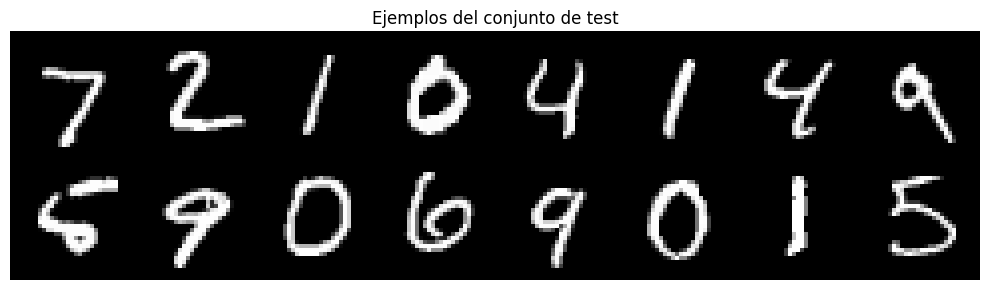

In [2]:
DATA_DIR = "../02_cnns/data"

transform = transforms.Compose([
    transforms.ToTensor(),          # → [0, 1]
])

train_dataset = datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} muestras  |  Test: {len(test_dataset)} muestras")

# Mostrar algunas imágenes de ejemplo
examples, labels = next(iter(test_loader))
grid = make_grid(examples[:16], nrow=8, padding=2)
plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Ejemplos del conjunto de test")
plt.tight_layout()
plt.show()

## 2. Arquitectura del Autoencoder

Usamos una arquitectura **fully-connected simétrica**:

| Capa          | Tamaño |
|---------------|--------|
| Input         | 784    |
| Encoder fc1   | 256    |
| Encoder fc2   | 128    |
| **Latente z** | **d**  |
| Decoder fc3   | 128    |
| Decoder fc4   | 256    |
| Output        | 784    |

La dimensión latente `d` es el único hiperparámetro que variamos.  
La función de pérdida es el **MSE** entre la entrada y la reconstrucción.

In [3]:
class Autoencoder(nn.Module):
    """Autoencoder fully-connected simétrico para imágenes 28x28."""

    def __init__(self, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 784 → 256 → 128 → latent_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        # Decoder: latent_dim → 128 → 256 → 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),   # salida en [0, 1] para coincidir con imágenes normalizadas
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


# Verificación rápida de dimensiones
_model = Autoencoder(latent_dim=2).to(DEVICE)
_x = torch.randn(4, 1, 28, 28).to(DEVICE)
_z = _model.encode(_x)
_xhat = _model.decode(_z)
print(f"Entrada: {_x.shape}  →  Latente: {_z.shape}  →  Reconstrucción: {_xhat.shape}")
del _model, _x, _z, _xhat

Entrada: torch.Size([4, 1, 28, 28])  →  Latente: torch.Size([4, 2])  →  Reconstrucción: torch.Size([4, 1, 28, 28])


## 3. Entrenamiento

Definimos las funciones de entrenamiento y evaluación, y luego entrenamos un autoencoder para cada dimensión latente `d ∈ {2, 4, 8, 16, 32}`.

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def get_latent_codes(model, loader, device, max_samples=5000):
    """Extrae todos los códigos latentes y etiquetas del loader."""
    model.eval()
    codes, labels_list = [], []
    total = 0
    for x, y in loader:
        x = x.to(device)
        z = model.encode(x).cpu().numpy()
        codes.append(z)
        labels_list.append(y.numpy())
        total += x.size(0)
        if total >= max_samples:
            break
    return np.concatenate(codes)[:max_samples], np.concatenate(labels_list)[:max_samples]

In [5]:
LATENT_DIMS  = [2, 4, 8, 16, 32]
NUM_EPOCHS   = 20
LEARNING_RATE = 1e-3
criterion    = nn.MSELoss()

# Diccionarios para guardar resultados
trained_models   = {}   # latent_dim → model
train_histories  = {}   # latent_dim → list of train losses
test_losses      = {}   # latent_dim → final test loss

for d in LATENT_DIMS:
    print(f"\n{'='*50}")
    print(f"  Entrenando Autoencoder  |  dim latente = {d}")
    print(f"{'='*50}")

    model     = Autoencoder(latent_dim=d).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history   = []

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        history.append(train_loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Época {epoch:3d}/{NUM_EPOCHS}  |  Loss (train): {train_loss:.5f}")

    final_test_loss = evaluate(model, test_loader, criterion, DEVICE)
    print(f"  → Loss final (test):  {final_test_loss:.5f}")

    trained_models[d]  = model
    train_histories[d] = history
    test_losses[d]     = final_test_loss

print("\n✓ Entrenamiento completo.")


  Entrenando Autoencoder  |  dim latente = 2
  Época   1/20  |  Loss (train): 0.06684
  Época   5/20  |  Loss (train): 0.04325
  Época  10/20  |  Loss (train): 0.04018
  Época  15/20  |  Loss (train): 0.03879
  Época  20/20  |  Loss (train): 0.03788
  → Loss final (test):  0.03835

  Entrenando Autoencoder  |  dim latente = 4
  Época   1/20  |  Loss (train): 0.06678
  Época   5/20  |  Loss (train): 0.03191
  Época  10/20  |  Loss (train): 0.02913
  Época  15/20  |  Loss (train): 0.02781
  Época  20/20  |  Loss (train): 0.02693
  → Loss final (test):  0.02746

  Entrenando Autoencoder  |  dim latente = 8
  Época   1/20  |  Loss (train): 0.06588
  Época   5/20  |  Loss (train): 0.02380
  Época  10/20  |  Loss (train): 0.02042
  Época  15/20  |  Loss (train): 0.01881
  Época  20/20  |  Loss (train): 0.01781
  → Loss final (test):  0.01784

  Entrenando Autoencoder  |  dim latente = 16
  Época   1/20  |  Loss (train): 0.06666
  Época   5/20  |  Loss (train): 0.01892
  Época  10/20  |  Los

## 4. Error de reconstrucción vs. dimensión latente

Comparamos las curvas de pérdida durante el entrenamiento y el error final en test.

> **Intuición:** a mayor `d`, más información puede preservar el autoencoder → menor error de reconstrucción. Con `d=2` el modelo debe comprimir muchísimo, por lo que las reconstrucciones serán más borrosas.

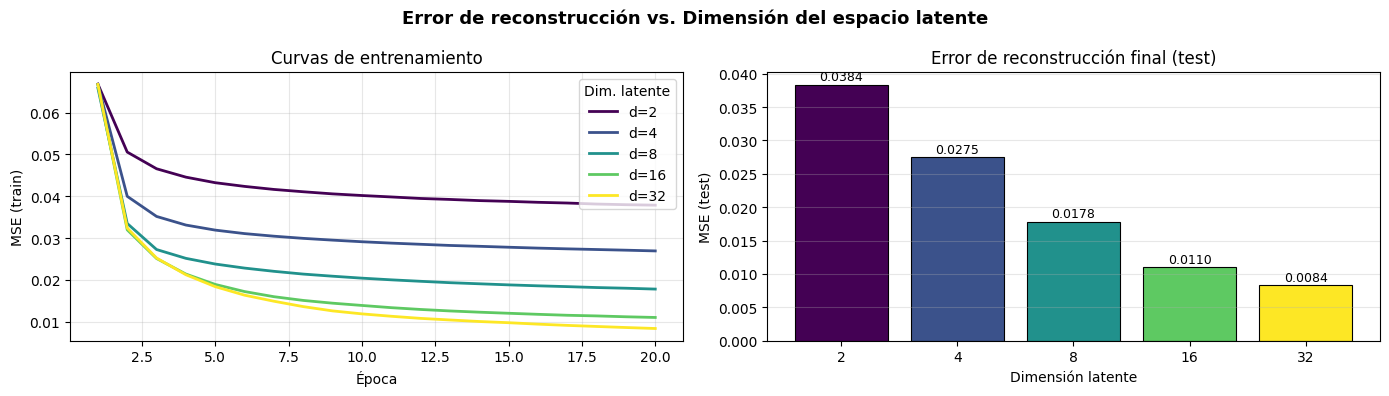


Resumen del error final en test:
  d= 2  →  MSE = 0.03835
  d= 4  →  MSE = 0.02746
  d= 8  →  MSE = 0.01784
  d=16  →  MSE = 0.01100
  d=32  →  MSE = 0.00836


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Izquierda: curvas de entrenamiento ---
ax = axes[0]
colors = cm.viridis(np.linspace(0, 1, len(LATENT_DIMS)))
for color, d in zip(colors, LATENT_DIMS):
    ax.plot(range(1, NUM_EPOCHS + 1), train_histories[d], label=f"d={d}", color=color, linewidth=2)
ax.set_xlabel("Época")
ax.set_ylabel("MSE (train)")
ax.set_title("Curvas de entrenamiento")
ax.legend(title="Dim. latente")
ax.grid(True, alpha=0.3)

# --- Derecha: error final en test ---
ax = axes[1]
dims  = list(test_losses.keys())
losses = list(test_losses.values())
bars = ax.bar([str(d) for d in dims], losses, color=colors, edgecolor="black", linewidth=0.8)
for bar, loss in zip(bars, losses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            f"{loss:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Dimensión latente")
ax.set_ylabel("MSE (test)")
ax.set_title("Error de reconstrucción final (test)")
ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Error de reconstrucción vs. Dimensión del espacio latente", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nResumen del error final en test:")
for d, loss in test_losses.items():
    print(f"  d={d:2d}  →  MSE = {loss:.5f}")

## 5. Visualización de reconstrucciones

Para cada dimensión latente mostramos pares **(original | reconstrucción)** de 8 imágenes de test, para ver visualmente cómo varía la calidad.

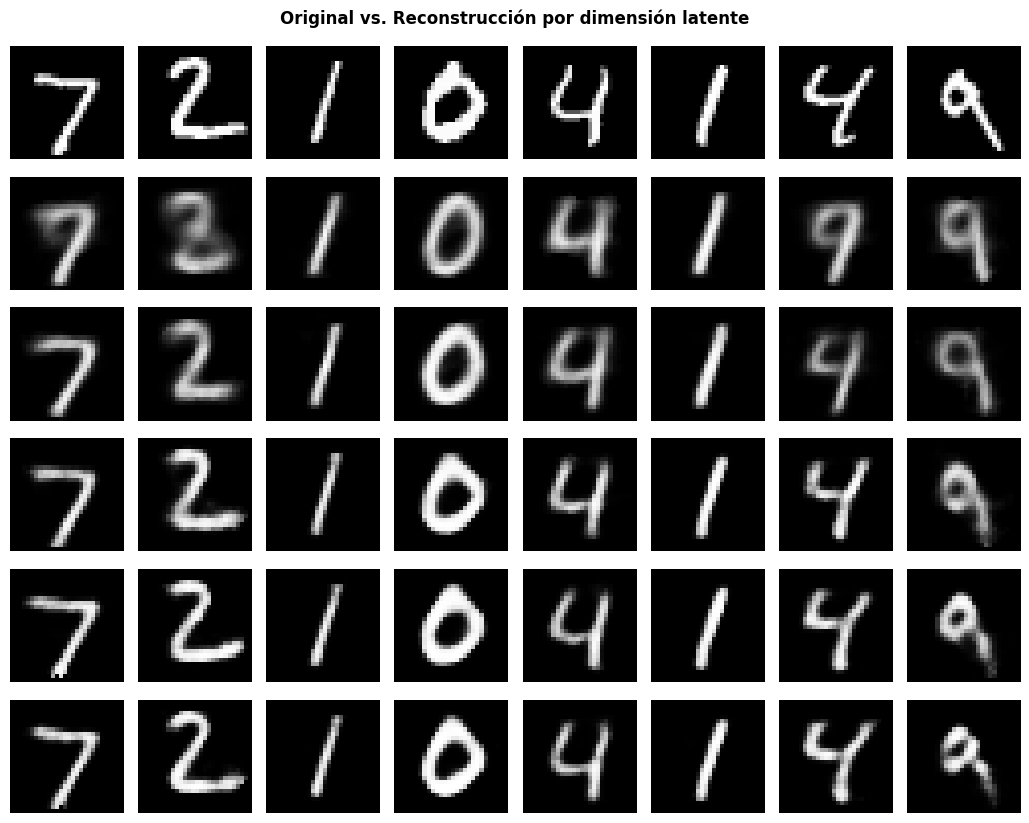

In [7]:
N_SHOW = 8   # número de imágenes a mostrar por fila

# Tomamos las mismas imágenes originales para todos los modelos
originals, _ = next(iter(test_loader))
originals = originals[:N_SHOW].to(DEVICE)

fig, axes = plt.subplots(len(LATENT_DIMS) + 1, N_SHOW, figsize=(N_SHOW * 1.3, (len(LATENT_DIMS) + 1) * 1.4))

# Primera fila: imágenes originales
for j in range(N_SHOW):
    axes[0, j].imshow(originals[j].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9, rotation=0, labelpad=45, va="center")

# Una fila por cada dimensión latente
for i, d in enumerate(LATENT_DIMS):
    model = trained_models[d]
    model.eval()
    with torch.no_grad():
        recons = model(originals)          # (N_SHOW, 1, 28, 28)
    for j in range(N_SHOW):
        axes[i + 1, j].imshow(recons[j].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[i + 1, j].axis("off")
    axes[i + 1, 0].set_ylabel(f"d={d}", fontsize=9, rotation=0, labelpad=30, va="center")

plt.suptitle("Original vs. Reconstrucción por dimensión latente", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Visualización del espacio latente

### ¿Qué queremos ver?
Idealmente, muestras de la **misma clase** deberían agruparse en el espacio latente. El autoencoder no tiene información de clase durante el entrenamiento, pero si la representación es buena, la estructura de los datos se refleja en `z`.

### Estrategia según la dimensión:

| Dimensión latente | Estrategia de visualización |
|---|---|
| `d = 2` | Proyección directa en 2D |
| `d > 2` | **PCA** → primeros 2 componentes principales |
| `d > 2` | **t-SNE** → embedding no lineal en 2D |

> **PCA** es lineal y rápido, pero puede no capturar toda la estructura.  
> **t-SNE** es no lineal, revela clusters locales, pero es más costoso computacionalmente.

### 6.1 Espacio latente 2D — proyección directa

Con `d=2` podemos hacer un scatter plot directo de las dos coordenadas latentes, coloreado por dígito.

/tmp/ipykernel_182547/521120650.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP_10 = plt.cm.get_cmap("tab10", 10)


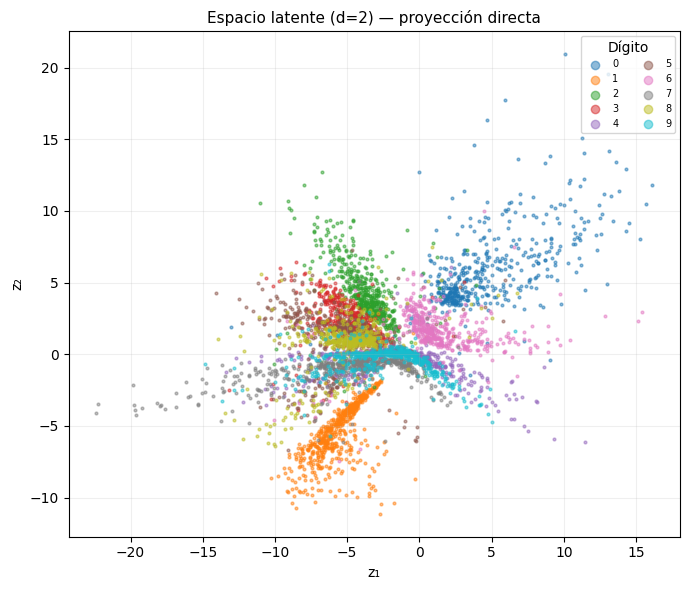

Códigos extraídos: (5000, 2)  |  Etiquetas: (5000,)


In [8]:
N_VIZ = 5000   # muestras para visualización

# Paleta con 10 colores distintos para los 10 dígitos
CMAP_10 = plt.cm.get_cmap("tab10", 10)

def scatter_latent(z2d, labels, title, ax):
    """Scatter plot 2D del espacio latente coloreado por dígito."""
    for digit in range(10):
        mask = labels == digit
        ax.scatter(z2d[mask, 0], z2d[mask, 1],
                   s=4, alpha=0.5, color=CMAP_10(digit), label=str(digit))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("z₁")
    ax.set_ylabel("z₂")
    ax.legend(title="Dígito", markerscale=3, fontsize=7,
              loc="upper right", ncol=2)
    ax.grid(True, alpha=0.2)


# Extraer códigos para d=2
model_2d = trained_models[2]
codes_2d, labels_2d = get_latent_codes(model_2d, test_loader, DEVICE, max_samples=N_VIZ)

fig, ax = plt.subplots(figsize=(7, 6))
scatter_latent(codes_2d, labels_2d, "Espacio latente (d=2) — proyección directa", ax)
plt.tight_layout()
plt.show()

print(f"Códigos extraídos: {codes_2d.shape}  |  Etiquetas: {labels_2d.shape}")

### 6.2 Espacio latente con PCA (d > 2)

Para dimensiones latentes mayores, aplicamos **PCA** y nos quedamos con los dos primeros componentes principales. También mostramos la **varianza explicada acumulada** para entender cuánta información capturan esos dos componentes.

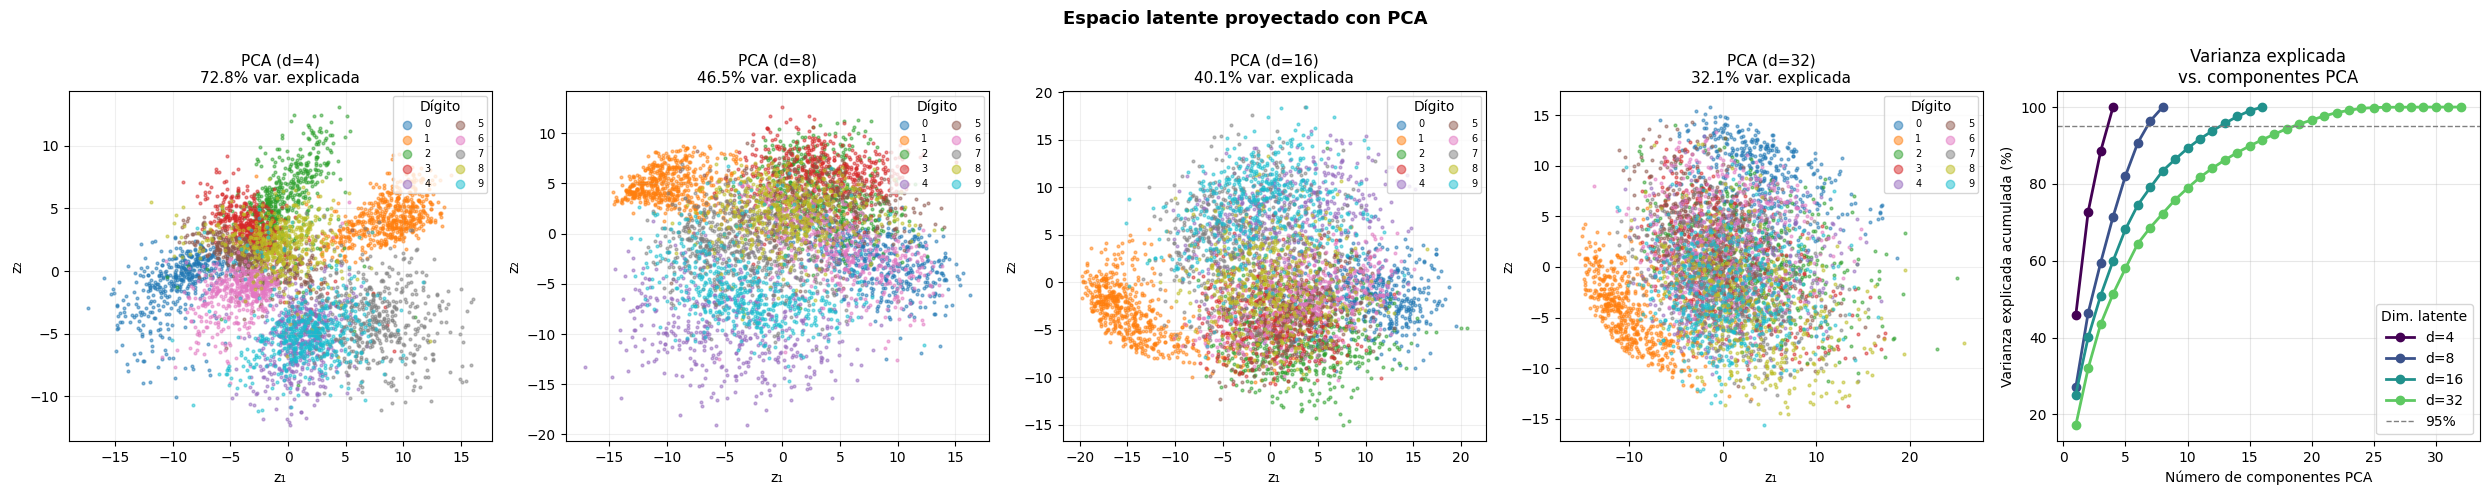

In [9]:
dims_high = [d for d in LATENT_DIMS if d > 2]   # [4, 8, 16, 32]

n_cols = len(dims_high) + 1   # +1 para la gráfica de varianza explicada
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

pca_results = {}   # guardamos para usar con t-SNE

for ax, d in zip(axes[:-1], dims_high):
    codes, labels = get_latent_codes(trained_models[d], test_loader, DEVICE, max_samples=N_VIZ)

    pca = PCA(n_components=2, random_state=42)
    z2d = pca.fit_transform(codes)
    pca_results[d] = (codes, labels)   # guardar para t-SNE

    var_exp = pca.explained_variance_ratio_.sum() * 100
    scatter_latent(z2d, labels, f"PCA (d={d})\n{var_exp:.1f}% var. explicada", ax)

# --- Varianza explicada acumulada vs. número de componentes PCA ---
ax_var = axes[-1]
for color, d in zip(colors, dims_high):
    codes, _ = pca_results[d]
    pca_full = PCA(n_components=min(d, codes.shape[1]), random_state=42)
    pca_full.fit(codes)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
    ax_var.plot(range(1, len(cum_var) + 1), cum_var, marker="o", label=f"d={d}", color=color, linewidth=2)

ax_var.axhline(95, color="gray", linestyle="--", linewidth=1, label="95%")
ax_var.set_xlabel("Número de componentes PCA")
ax_var.set_ylabel("Varianza explicada acumulada (%)")
ax_var.set_title("Varianza explicada\nvs. componentes PCA")
ax_var.legend(title="Dim. latente")
ax_var.grid(True, alpha=0.3)

plt.suptitle("Espacio latente proyectado con PCA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.3 Espacio latente con t-SNE (d > 2)

**t-SNE** (t-distributed Stochastic Neighbor Embedding) es un método no lineal que trata de preservar las distancias locales entre puntos. Suele revelar clusters más compactos que PCA, aunque no conserva la estructura global.

> **Nota:** t-SNE es más lento que PCA. En la práctica se suele aplicar primero PCA para reducir a ~50 dimensiones y luego t-SNE.

Para acelerar el cómputo usamos solo **2 000 muestras** y aplicamos PCA previo cuando `d > 10`.

  Calculando t-SNE para d=2... listo.
  Calculando t-SNE para d=4... listo.
  Calculando t-SNE para d=8... listo.
  Calculando t-SNE para d=16... listo.
  Calculando t-SNE para d=32... listo.


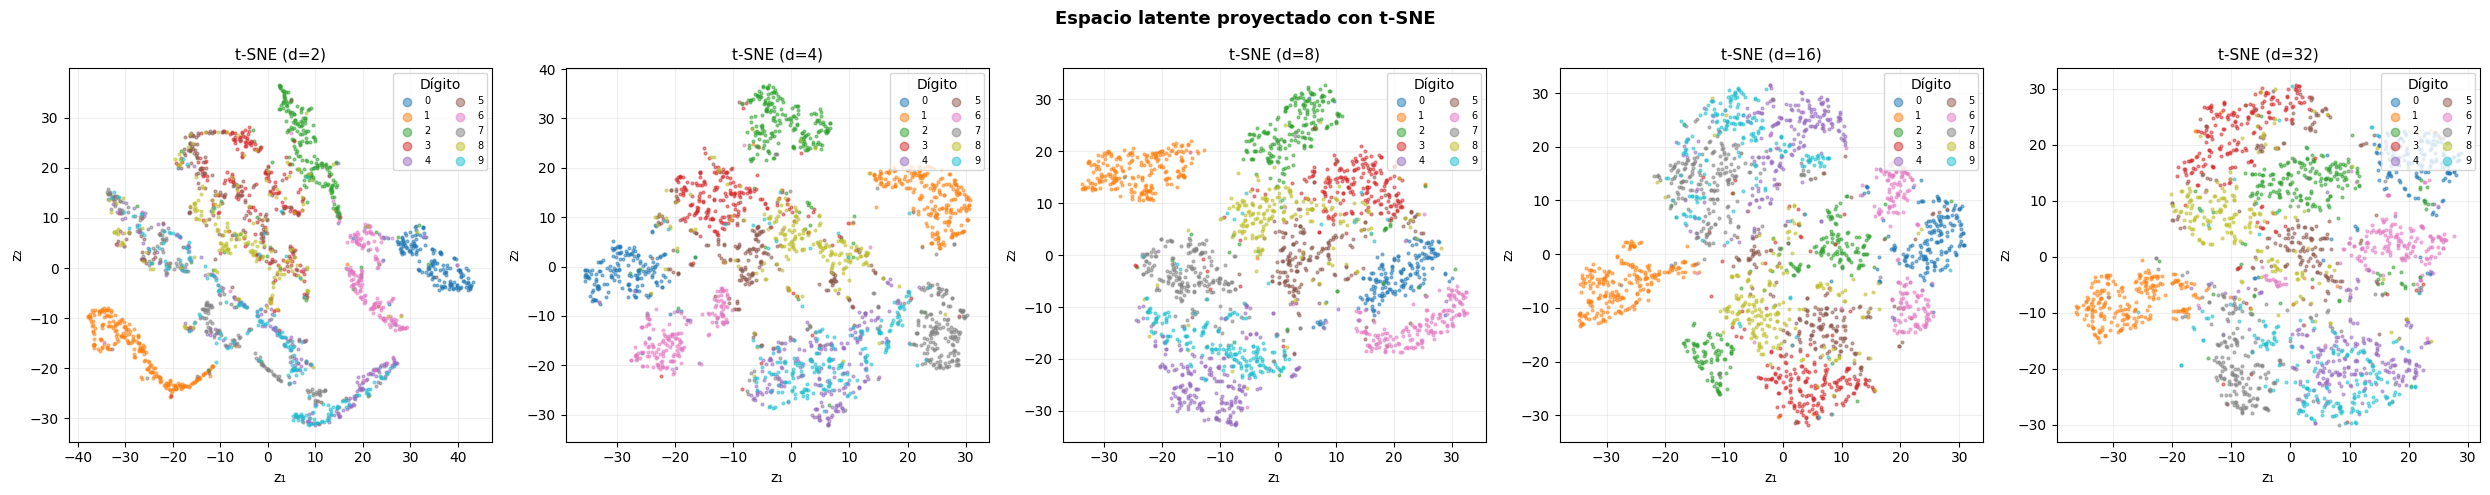

In [10]:
N_TSNE = 2000   # t-SNE es O(n²), usamos un subset

# También incluimos d=2 para comparar directamente
all_dims_for_tsne = LATENT_DIMS  # [2, 4, 8, 16, 32]

n_rows = 1
n_cols = len(all_dims_for_tsne)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5))

for ax, d in zip(axes, all_dims_for_tsne):
    codes, labels = get_latent_codes(trained_models[d], test_loader, DEVICE, max_samples=N_TSNE)

    # Preprocesado PCA opcional antes de t-SNE (recomendado para d grande)
    codes_in = codes
    if d > 10:
        n_pca = min(d, 10)
        pca_pre = PCA(n_components=n_pca, random_state=42)
        codes_in = pca_pre.fit_transform(codes)

    print(f"  Calculando t-SNE para d={d}...", end=" ", flush=True)
    tsne = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42, n_jobs=-1)
    z2d = tsne.fit_transform(codes_in)
    print("listo.")

    scatter_latent(z2d, labels, f"t-SNE (d={d})", ax)

plt.suptitle("Espacio latente proyectado con t-SNE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Interpolación en el espacio latente

Una de las propiedades más interesantes de los autoencoders es que el espacio latente es **continuo**: si interpolamos linealmente entre dos códigos `z₁` y `z₂`, las reconstrucciones intermedias son imágenes "plausibles".

$$z(\alpha) = (1 - \alpha)\, z_1 + \alpha\, z_2, \quad \alpha \in [0, 1]$$

Esto es posible porque el encoder aprende una representación suave del espacio de datos.

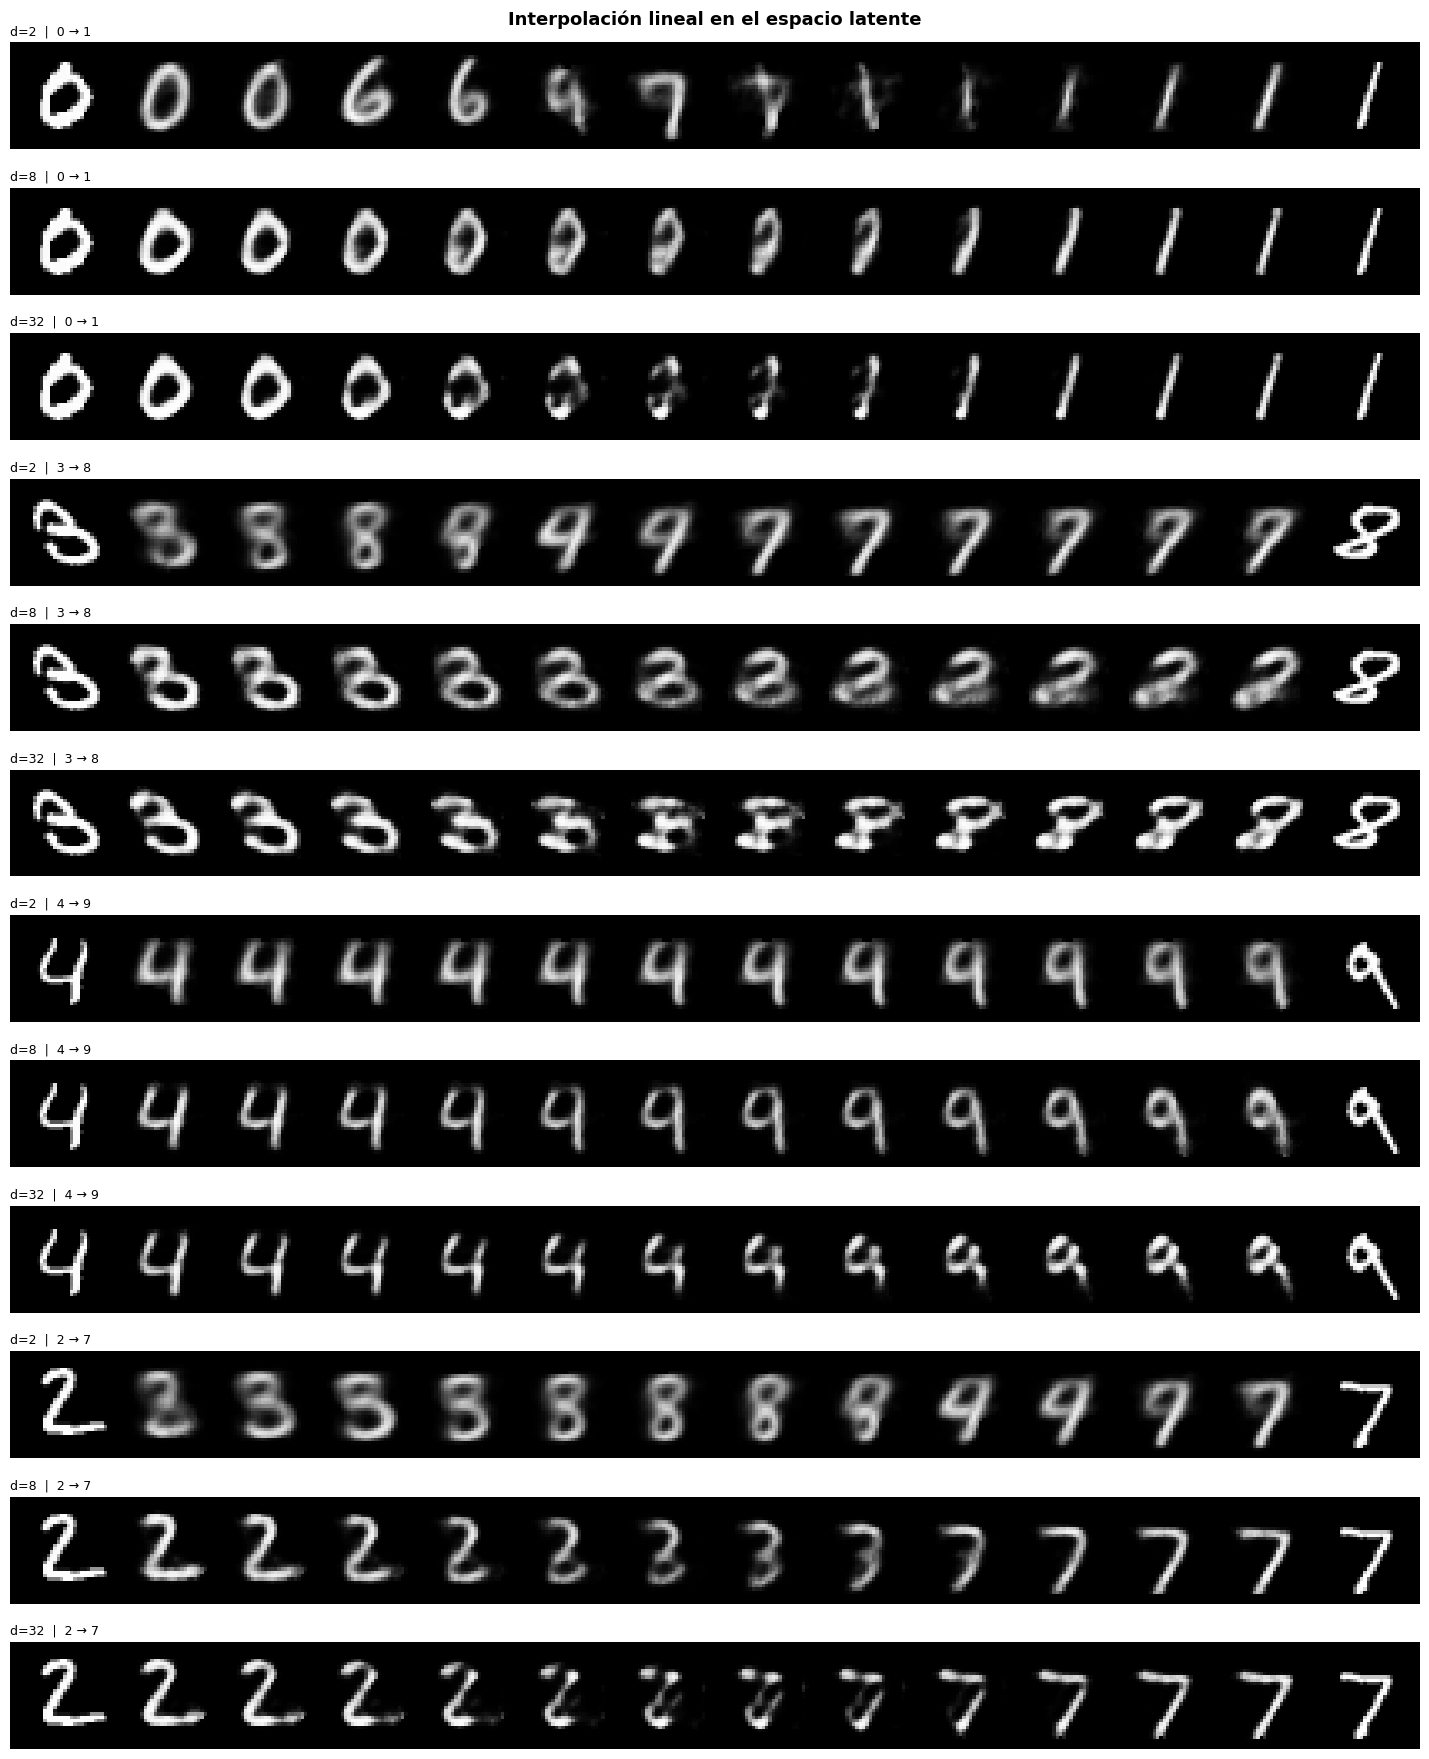

In [12]:
def interpolate_latent(model, img_a, img_b, n_steps=10, device=DEVICE):
    """Interpola linealmente en el espacio latente entre dos imágenes."""
    model.eval()
    with torch.no_grad():
        za = model.encode(img_a.unsqueeze(0).to(device))   # (1, d)
        zb = model.encode(img_b.unsqueeze(0).to(device))   # (1, d)
        alphas = torch.linspace(0, 1, n_steps).to(device)
        z_interp = torch.stack([(1 - a) * za + a * zb for a in alphas]).squeeze(1)   # (n_steps, d)
        imgs = model.decode(z_interp).cpu()                # (n_steps, 1, 28, 28)
    return imgs


# Tomamos un par de imágenes de clases distintas del test set
test_images_all  = test_dataset.data.float() / 255.0  # (10000, 28, 28)
test_labels_all  = test_dataset.targets

N_STEPS    = 12
N_PAIRS    = 4    # cuántos pares de dígitos mostrar
PAIRS      = [(0, 1), (3, 8), (4, 9), (2, 7)]  # pares de dígitos a interpolar

fig, big_axes = plt.subplots(len(PAIRS) * len([2, 8, 32]), 1,
                              figsize=(N_STEPS * 1.2, len(PAIRS) * len([2, 8, 32]) * 1.5))
big_axes = big_axes.flatten()

row = 0
for digit_a, digit_b in PAIRS:
    idx_a = (test_labels_all == digit_a).nonzero(as_tuple=True)[0][0]
    idx_b = (test_labels_all == digit_b).nonzero(as_tuple=True)[0][0]
    img_a = test_images_all[idx_a].unsqueeze(0)   # (1, 28, 28)
    img_b = test_images_all[idx_b].unsqueeze(0)

    for d in [2, 8, 32]:
        model = trained_models[d]
        interp_imgs = interpolate_latent(model, img_a, img_b, n_steps=N_STEPS)

        ax = big_axes[row]
        row += 1

        # Concatenar todas las imágenes en una franja horizontal
        strip = torch.cat([img_a.unsqueeze(0)] + [interp_imgs[i].unsqueeze(0) for i in range(N_STEPS)] + [img_b.unsqueeze(0)], dim=0)
        grid = make_grid(strip, nrow=len(strip), padding=2)
        ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(f"d={d}  |  {digit_a} → {digit_b}", fontsize=9, loc="left")

plt.suptitle("Interpolación lineal en el espacio latente", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Resumen y conclusiones

### ¿Qué aprendimos?

| Concepto | Observación |
|---|---|
| **Compresión** | Con `d=2` se pierde mucha información; las reconstrucciones son más borrosas. |
| **Trade-off** | A mayor `d`, menor error de reconstrucción pero menor compresión. |
| **Espacio latente** | Con `d=2` la estructura de los dígitos ya es visible directamente. |
| **PCA** | Revela la varianza principal de la representación latente. Con `d` grande, los primeros 2 CP explican menos varianza. |
| **t-SNE** | Revela clusters más compactos y separados que PCA, especialmente para `d` grande. |
| **Interpolación** | El espacio latente es suave: las transiciones intermedias son imágenes coherentes. |

### Limitaciones del autoencoder estándar

- El espacio latente **no tiene estructura probabilística**: no podemos muestrear puntos nuevos con garantía de que produzcan imágenes realistas.
- Este problema se resuelve con el **Variational Autoencoder (VAE)**, que aprende una distribución sobre `z` en lugar de un punto.

### ¿Qué sigue?
- **VAE**: añade un prior gaussiano al espacio latente → permite generación.
- **Conditional Autoencoder**: condicionamos en la clase → control del contenido generado.
- **Convolutional Autoencoder**: reemplaza las capas FC por convoluciones → mejor calidad visual.